In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")


import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report,precision_recall_curve,average_precision_score
)

pd.set_option("display.width", 130)


sns.set(style="whitegrid")


In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(283726, 31)

In [4]:
X = df.drop(columns=['Class'])
y = df['Class']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
raw_cols = ['Time', 'Amount']
pca_cols = [f'V{i}' for i in range(1, 29)]


num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


processor = ColumnTransformer([
    ('num', num_pipeline, raw_cols),
    ('pca_pass', 'passthrough', pca_cols)
])



In [7]:
processor.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('pca_pass', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [8]:
x_train_transformed = processor.transform(x_train)
x_test_transformed = processor.transform(x_test)

In [9]:
scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [10]:
model_paths = {
    "Logistic Regression": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-1375070ca880457fba06927fe253cdd4\artifacts",
    "Random Forest": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-3e17afcaf4f449639eb06241cf080b0c\artifacts",
    "Decision Tree": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-3f876935665049089a408d04c8bb59e7\artifacts",
    "XGBoost": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-86bdd9ca40a84981b72223685c1701bf\artifacts",
    "CatBoost": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-d3dad814f65e450fb256718fe418b8b8\artifacts",
    "KNN": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-e647dc58adb44d66a83123f59f77d2da\artifacts",
    "SVM": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-eb510b2790eb47a8b7051ab7fe7107d3\artifacts",
    "Naive Bayes": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-fed91f1ba36e491dbef81a191e26a35e\artifacts",
    
}

results = []

for name, path in model_paths.items():

    model = mlflow.sklearn.load_model(path)

    y_pred = model.predict(x_test_transformed)

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

    
    results.append(row)
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("F1", ascending=False).reset_index(drop=True)

results_df


,Model,Accuracy,Precision,Recall,F1
0,XGBoost,0.999577,0.961039,0.778947,0.860465
1,Random Forest,0.999524,0.985714,0.726316,0.836364
2,KNN,0.999471,0.971014,0.705263,0.817073
3,CatBoost,0.999383,0.826087,0.800000,0.812834
4,SVM,0.999348,0.983333,0.621053,0.761290
5,Decision Tree,0.999031,0.717391,0.694737,0.705882
6,Logistic Regression,0.999137,0.848485,0.589474,0.695652
7,Naive Bayes,0.977549,0.057764,0.810526,0.107843


In [11]:
model_paths = {"Random Forest Smote": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\model_m-070da4b85f0749de8d9d6d5b80036ec3\m-070da4b85f0749de8d9d6d5b80036ec3\artifacts",
    "CatBoost Smote": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\model_m-b2bbacd294e34b14b88e7b2540d98648\m-b2bbacd294e34b14b88e7b2540d98648\artifacts",
    "XGBoost Smote": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\model_m-ffeceb6c96804f8d814aeb3a5cd078ff\m-ffeceb6c96804f8d814aeb3a5cd078ff\artifacts",
}
for model_name, model_path in model_paths.items():

    model = mlflow.sklearn.load_model(model_path)


    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1
0,XGBoost,0.999577,0.961039,0.778947,0.860465
1,Random Forest,0.999524,0.985714,0.726316,0.836364
2,Random Forest Smote,0.999454,0.910256,0.747368,0.820809
3,KNN,0.999471,0.971014,0.705263,0.817073
4,CatBoost,0.999383,0.826087,0.800000,0.812834
5,XGBoost Smote,0.999348,0.815217,0.789474,0.802139
6,SVM,0.999348,0.983333,0.621053,0.761290
7,Decision Tree,0.999031,0.717391,0.694737,0.705882
8,Logistic Regression,0.999137,0.848485,0.589474,0.695652
9,CatBoost Smote,0.998643,0.567164,0.800000,0.663755


Models to go forward with is:
- XGBoost since it has the highest precision and the recall is one of the highest.
- Random Forest since it has the highest precision and even though recall is lower it is still higher than most and has the second highest F1 Score.
- Cat Boost since the recall is significantly higher than the recall for KNN. In our model, recall is one of the main metrics since missing fraud transactions are much more costly than falsely detecting legitmate transactions.

Naive Bayes has high recall but precision is too low that we do not wqant too many instances where we predict fraud when it is legitimate.

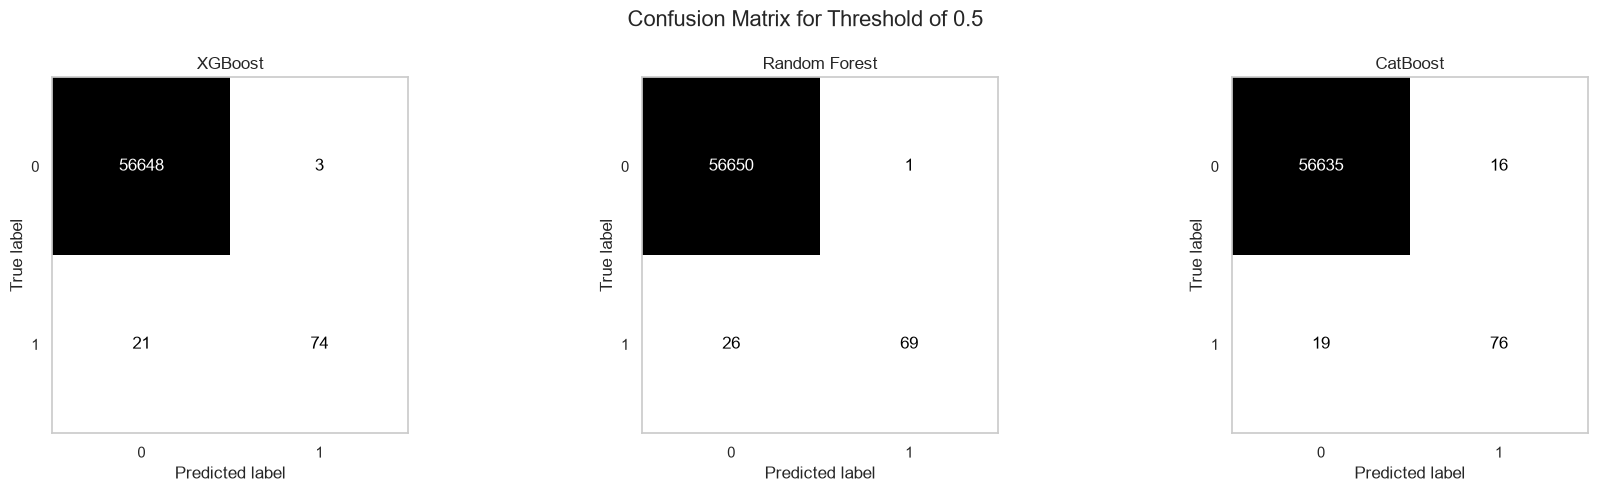

In [12]:
model_paths = {
    "XGBoost": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-86bdd9ca40a84981b72223685c1701bf\artifacts",
    "Random Forest": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-3e17afcaf4f449639eb06241cf080b0c\artifacts",
    "CatBoost": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-d3dad814f65e450fb256718fe418b8b8\artifacts",
}
fig,axes = plt.subplots(1,3,figsize = (18,5))

for ax, (model_name, model_path) in zip(axes,model_paths.items()):
    model = mlflow.sklearn.load_model(model_path)
    y_pred = model.predict(x_test_transformed)
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred,ax = ax,colorbar= False,values_format='d',cmap = 'Greys')
    ax.set_title(model_name)
    ax.grid(False)
plt.suptitle('Confusion Matrix for Threshold of 0.5',fontsize = 16)
plt.tight_layout()
plt.show()

In [ ]:
model_paths = {
    "XGBoost": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-86bdd9ca40a84981b72223685c1701bf\artifacts",
    "Random Forest": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-3e17afcaf4f449639eb06241cf080b0c\artifacts",
    "CatBoost": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-d3dad814f65e450fb256718fe418b8b8\artifacts",
}

mlflow.set_experiment("Threshold Evaluation")

for model_name, model_path in model_paths.items():

    with mlflow.start_run(run_name=f"{model_name}_PR_Curve"):

        model = mlflow.sklearn.load_model(model_path)

        y_scores = model.predict_proba(x_test_transformed)[:, 1]

        precision, recall, _ = precision_recall_curve(y_test, y_scores)

        ap = average_precision_score(y_test, y_scores)
        roc_auc = roc_auc_score(y_test, y_scores)

        plt.figure(figsize=(6,5))
        plt.plot(recall, precision, linewidth=2)
        plt.title(model_name)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.xlim(0,1)
        plt.ylim(0,1.05)
        plt.grid(True)

        filename = f"{model_name}_PR_Curve.png"
        fig_single.savefig(filename, bbox_inches="tight")
        mlflow.log_metric("average_precision", ap)
        mlflow.log_metric("roc_auc", roc_auc)

        mlflow.log_artifact(filename)

        plt.close()

2026/07/20 06:05:53 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/20 06:05:53 INFO mlflow.store.db.utils: Updating database tables
2026/07/20 06:05:55 INFO mlflow.tracking.fluent: Experiment with name 'Threshold Evaluation' does not exist. Creating a new experiment.


In [14]:
mlflow.set_experiment("Threshold Evaluation")

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

models = {
    "XGBoost": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-86bdd9ca40a84981b72223685c1701bf\artifacts",
    "Random Forest": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-3e17afcaf4f449639eb06241cf080b0c\artifacts",
    "CatBoost": r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-d3dad814f65e450fb256718fe418b8b8\artifacts"
}

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

fig, axes = plt.subplots(3, 5, figsize=(25, 15))

for row, (model_name, model_path) in enumerate(models.items()):

    model = mlflow.sklearn.load_model(model_path)

    y_prob = model.predict_proba(x_test_transformed)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)

    for col, threshold in enumerate(thresholds):

        with mlflow.start_run(run_name=f"{model_name}_threshold_{threshold}"):

            y_pred = (y_prob >= threshold).astype(int)

            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            accuracy = accuracy_score(y_test, y_pred)

            # Log parameters
            mlflow.log_param("model", model_name)
            mlflow.log_param("threshold", threshold)

            # Log metrics
            mlflow.log_metric("accuracy", accuracy)
            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1_score", f1)
            mlflow.log_metric("roc_auc", roc_auc)

            results.append({
                "Model": model_name,
                "Threshold": threshold,
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall": recall,
                "F1": f1
            })

            cm = confusion_matrix(y_test, y_pred)
           
            fig_single, ax_single = plt.subplots(figsize=(5, 5))

            ConfusionMatrixDisplay(confusion_matrix=cm).plot(
                ax=ax_single,
                colorbar=False,
                values_format="d",
                cmap="Blues"
            )

            ax_single.set_title(f"{model_name} - Threshold {threshold}")

            filename = f"{model_name}_{threshold}_CM.png"

            fig_single.savefig(filename, bbox_inches="tight")

            mlflow.log_artifact(filename)

            plt.close(fig_single)

            disp = ConfusionMatrixDisplay(confusion_matrix=cm)

            disp.plot(
                ax=axes[row, col],
                colorbar=False,
                values_format="d",
                cmap = 'Blues'
            )
            cm_filename = f"{model_name}_{threshold}_cm.png"

            disp.figure_.savefig(cm_filename, bbox_inches="tight")

            mlflow.log_artifact(cm_filename)

            plt.close(disp.figure_)

            if row == 0:
                axes[row, col].set_title(f"Threshold = {threshold}")

            if col == 0:
                axes[row, col].set_ylabel(model_name)
for ax in axes.flat:
    ax.grid(False)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)

results_df

<Figure size 640x480 with 0 Axes>

,Model,Threshold,Accuracy,Precision,Recall,F1
0,XGBoost,0.1,0.999436,0.853933,0.800000,0.826087
1,XGBoost,0.2,0.999542,0.915663,0.800000,0.853933
2,XGBoost,0.3,0.999559,0.926829,0.800000,0.858757
3,XGBoost,0.4,0.999577,0.961039,0.778947,0.860465
4,XGBoost,0.5,0.999577,0.961039,0.778947,0.860465
5,Random Forest,0.1,0.999137,0.725490,0.778947,0.751269
6,Random Forest,0.2,0.999401,0.858824,0.768421,0.811111
7,Random Forest,0.3,0.999454,0.900000,0.757895,0.822857
8,Random Forest,0.4,0.999489,0.934211,0.747368,0.830409
9,Random Forest,0.5,0.999524,0.985714,0.726316,0.836364


## Chosen Model

Out of the models, I am going for the XGBoost with threshold of 0.3. It gives a precision of 0.93(which is high) and a recall of 0.8.

In [15]:
model_uri = r"C:\Training\Credit-Card-Fraud-Detection\mlruns\1\models\m-86bdd9ca40a84981b72223685c1701bf\artifacts"
mlflow.register_model(
    model_uri=model_uri,
    name="Fraud Detection Model"
)


Successfully registered model 'Fraud Detection Model'.
Created version '1' of model 'Fraud Detection Model'.


<ModelVersion: aliases=[], creation_timestamp=1784523976956, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1784523976956, metrics=None, model_id=None, name='Fraud Detection Model', params=None, run_id=None, run_link=None, source='C:\\Training\\Credit-Card-Fraud-Detection\\mlruns\\1\\models\\m-86bdd9ca40a84981b72223685c1701bf\\artifacts', status='READY', status_message=None, tags={}, user_id=None, version=1, workspace='default'>